In [ ]:
from datetime import date, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# from sklearn.preprocessing import OneHotEncoder

1.データ読み込み

In [ ]:
# 使用するカラムを指定

usecols = ["Year", "Month", "Day", "Hour", "Minute", "Temperature", "Clearsky GHI", "Cloud Type", "Dew Point", "DHI", "DNI",
            "GHI", "Relative Humidity","Pressure", "Precipitable Water", "Wind Direction", "Wind Speed"]

In [3]:
# ファイルの読み込み＋複数年を合算


df_weather_yamanashi = pd.DataFrame()

for year in range(2016, 2021):

    file_path = f"../data/weather_yamanashi_{year}.csv"
    print(file_path)
    df = pd.read_csv(file_path, skiprows=2, usecols=usecols)

    if df_weather_yamanashi.empty:
        # print("empty")
        df_weather_yamanashi = df
    else:
        # print("not empty")
        df_weather_yamanashi =  pd.concat([df_weather_yamanashi, df])

df_weather_yamanashi.reset_index(drop = True)
    


../data/weather_yamanashi_2016.csv
../data/weather_yamanashi_2017.csv
../data/weather_yamanashi_2018.csv
../data/weather_yamanashi_2019.csv
../data/weather_yamanashi_2020.csv


,Year,Month,Day,Hour,Minute,Temperature,Clearsky GHI,Cloud Type,Dew Point,DHI,DNI,GHI,Relative Humidity,Pressure,Precipitable Water,Wind Direction,Wind Speed
0,2016,1,1,0,0,5.2,327.0,0.0,-5.2,65.0,801.0,327.0,47.19,1001.0,0.3,309.0,2.6
1,2016,1,1,1,0,6.7,463.0,0.0,-5.7,76.0,886.0,463.0,40.89,1001.0,0.3,310.0,2.7
2,2016,1,1,2,0,7.9,541.0,0.0,-5.5,80.0,916.0,541.0,38.04,1000.0,0.4,312.0,2.6
3,2016,1,1,3,0,8.7,563.0,0.0,-5.1,78.0,935.0,563.0,37.18,1000.0,0.4,311.0,2.4
4,2016,1,1,4,0,9.0,520.0,0.0,-4.7,74.0,919.0,520.0,37.59,1000.0,0.4,309.0,1.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43843,2020,12,31,19,0,-0.6,0.0,0.0,-6.4,0.0,0.0,0.0,64.98,986.0,0.5,267.0,1.7
43844,2020,12,31,20,0,-0.4,0.0,0.0,-6.1,0.0,0.0,0.0,65.48,987.0,0.5,272.0,1.7
43845,2020,12,31,21,0,-0.1,0.0,0.0,-5.9,0.0,0.0,0.0,65.05,987.0,0.5,278.0,1.9
43846,2020,12,31,22,0,1.0,0.0,0.0,-5.5,0.0,0.0,0.0,62.03,988.0,0.5,285.0,2.2


In [ ]:
df_weather_yamanashi.head()

2.データ品質の確認（基本統計量、欠損値、表記ブレの確認）

In [5]:
# 欠損値の確認

df_weather_yamanashi.isnull().sum()

Year                  0
Month                 0
Day                   0
Hour                  0
Minute                0
Temperature           0
Clearsky GHI          0
Cloud Type            0
Dew Point             0
DHI                   0
DNI                   0
GHI                   0
Relative Humidity     0
Pressure              0
Precipitable Water    0
Wind Direction        0
Wind Speed            0
dtype: int64

In [6]:
# 質的変数の表記ブレの確認
# df_weather_yamanashi["Cloud Type"].unique()
df_weather_yamanashi["Cloud Type"].value_counts()


Cloud Type
0.0    12724
7.0    11393
1.0     5676
3.0     4974
4.0     4657
6.0     3142
8.0     1086
9.0      196
Name: count, dtype: int64

In [7]:
# 基本統計量の確認
df_weather_yamanashi.describe()

,Year,Month,Day,Hour,Minute,Temperature,Clearsky GHI,Cloud Type,Dew Point,DHI,DNI,GHI,Relative Humidity,Pressure,Precipitable Water,Wind Direction,Wind Speed
count,43848.000000,43848.000000,43848.000000,43848.000000,43848.0,43848.000000,43848.000000,43848.000000,43848.000000,43848.000000,43848.000000,43848.000000,43848.000000,43848.000000,43848.000000,43848.000000,43848.000000
mean,2018.000000,6.521073,15.735085,11.500000,0.0,15.255993,236.558429,3.381705,8.782314,78.417967,170.113118,176.690932,66.538316,992.398946,2.561661,205.299808,1.290303
std,1.415004,3.449252,8.802492,6.922265,0.0,9.427810,308.845508,2.944900,9.544105,113.127252,277.119403,257.820099,12.825443,5.596738,1.890652,103.183242,0.878704
min,2016.000000,1.000000,1.000000,0.000000,0.0,-7.800000,0.000000,0.000000,-16.700000,0.000000,0.000000,0.000000,25.360000,951.000000,0.200000,0.000000,0.100000
25%,2017.000000,4.000000,8.000000,5.750000,0.0,7.100000,0.000000,0.000000,0.400000,0.000000,0.000000,0.000000,57.900000,989.000000,0.900000,128.000000,0.700000
50%,2018.000000,7.000000,16.000000,11.500000,0.0,15.600000,0.000000,3.000000,9.200000,0.000000,0.000000,0.000000,69.000000,993.000000,2.000000,218.500000,1.000000
75%,2019.000000,10.000000,23.000000,17.250000,0.0,23.300000,487.000000,7.000000,17.300000,129.000000,275.000000,318.000000,77.500000,996.000000,4.100000,294.000000,1.600000
max,2020.000000,12.000000,31.000000,23.000000,0.0,36.300000,1025.000000,9.000000,26.000000,495.000000,981.000000,1025.000000,88.290000,1010.000000,8.200000,360.000000,8.500000


3.可視化

In [ ]:
#分布の確認

/var/folders/jd/9q0s8pbn2lx60v_8z7wy2rth0000gn/T/ipykernel_268/1181444429.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


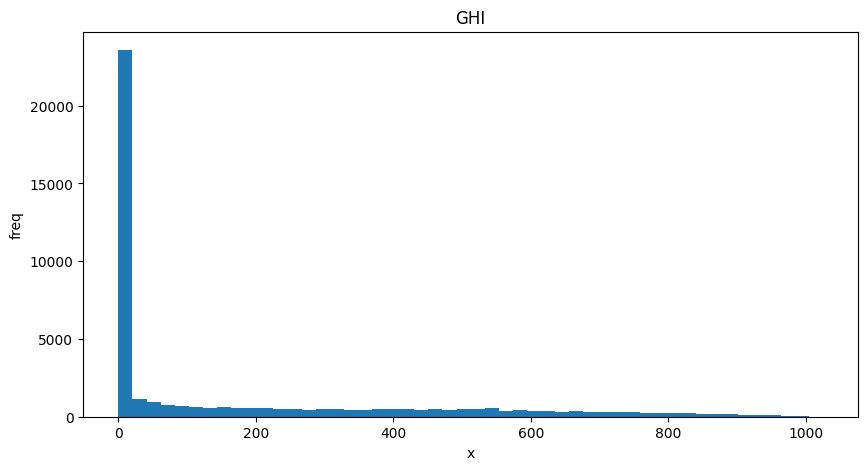

In [8]:
# GHIのヒストグラム

x = df_weather_yamanashi["GHI"]

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(x, bins = 50)
ax.set_title("GHI")
ax.set_xlabel("x")
ax.set_ylabel('freq')
fig.show()

/var/folders/jd/9q0s8pbn2lx60v_8z7wy2rth0000gn/T/ipykernel_268/327199504.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


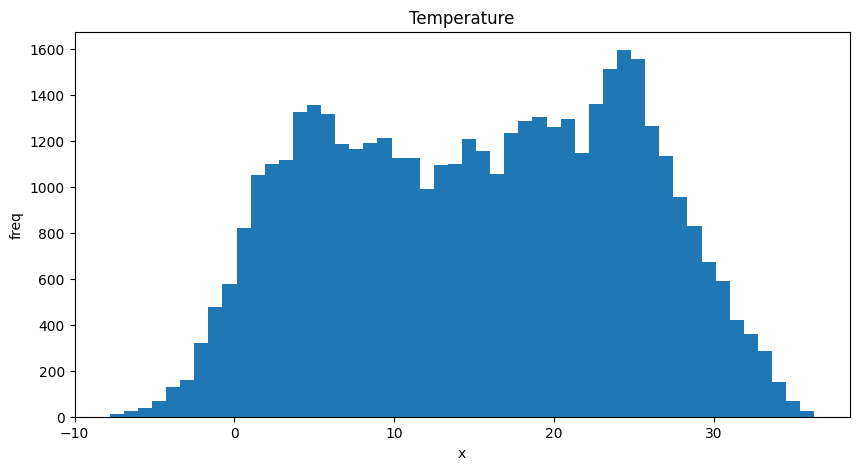

In [9]:
# Temparatureのヒストグラム

x = df_weather_yamanashi["Temperature"]

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(x, bins = 50)
ax.set_title("Temperature")
ax.set_xlabel("x")
ax.set_ylabel('freq')
fig.show()

In [10]:
# 時刻をつくる
# 元データがtz = 0なので、utc指定。
df_weather_yamanashi["dt"] = pd.to_datetime(df_weather_yamanashi[["Year", "Month", "Day", "Hour"]], utc = True)

In [11]:
# time zoneの処理
# 元データはtz=0, local tz=9なので、hourを+9する。
# 23時とかは32時間とかになるからちゃんと計算する。

df_weather_yamanashi["jst"] = df_weather_yamanashi["dt"] + pd.Timedelta(hours=9)

In [12]:
#日射量から、発電量を作成
# 発電量 = GHI[W/㎡] ＊ 1 [hour] * 発電効率　＊　温度補正 * パネル面積
# 発電量[Wh/m2] = GHI ＊ 1 ＊ 0.18 * (1 - 0.004 * (Temperature - 25)) * 1
# 本来は外気気温ではなく、パネル温度で補正をかける

# [Wh]
df_weather_yamanashi["pv"] = df_weather_yamanashi["GHI"] * 1 * 0.18 * (1 - 0.004 * (df_weather_yamanashi["Temperature"] - 25))  * 1



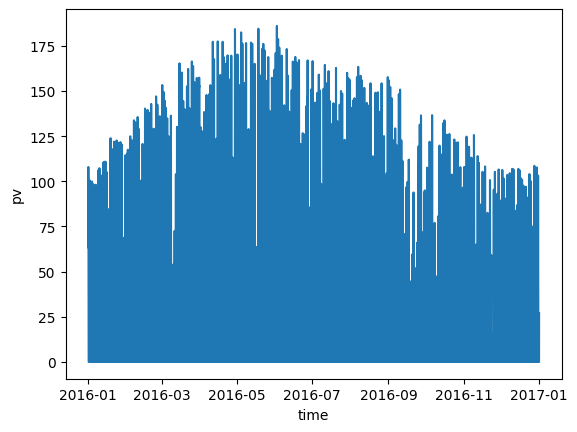

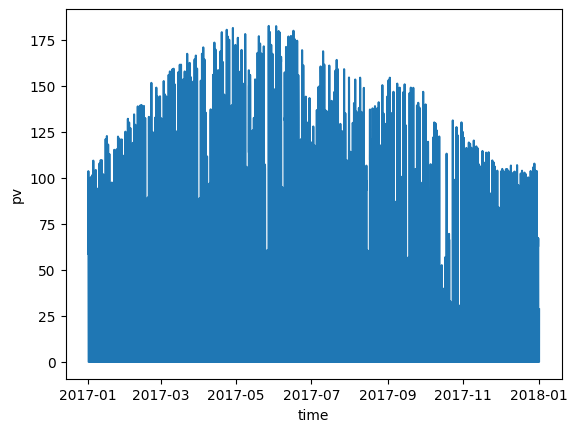

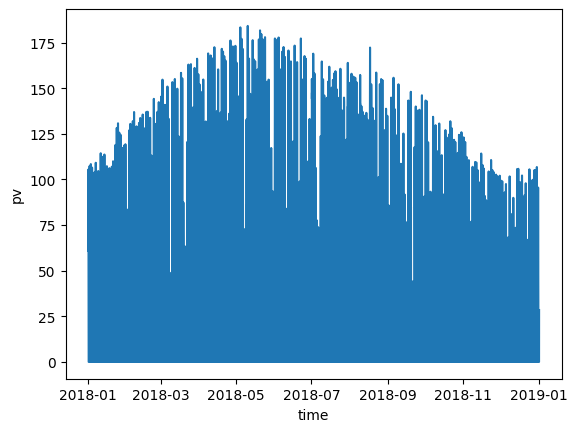

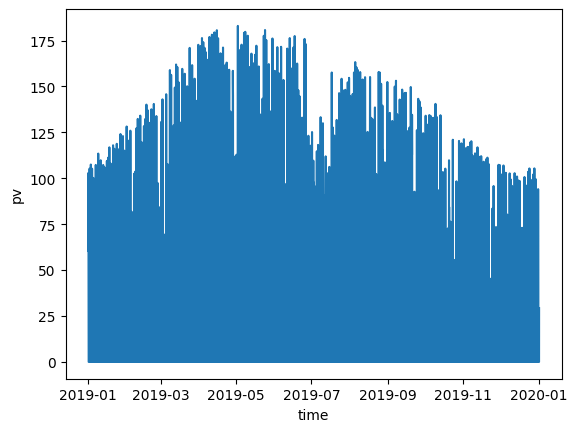

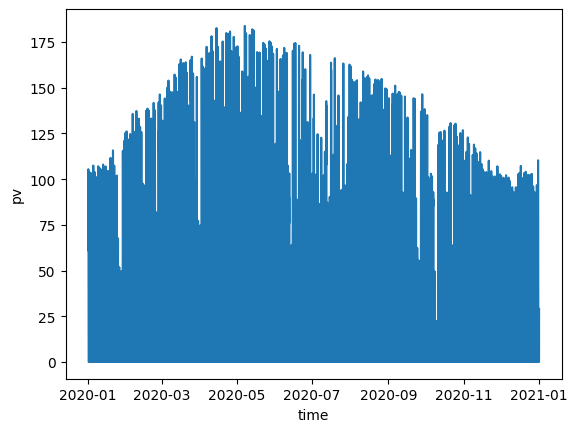

In [ ]:
# 時系列で発電量をみる。
# 年毎に分ける

for i in range(2016, 2021):
    x = df_weather_yamanashi["jst"][df_weather_yamanashi["Year"] == i]
    y = df_weather_yamanashi["pv"][df_weather_yamanashi["Year"] == i]

    plt.plot(x, y)
    plt.xlabel("time")
    plt.ylabel("pv")
    plt.show()


In [ ]:
# カクツキはあるが、季節によって発電量も変化している。春〜夏が多くて、秋〜冬が少ない
# 季節性がある
# 年毎の差はほとんどない

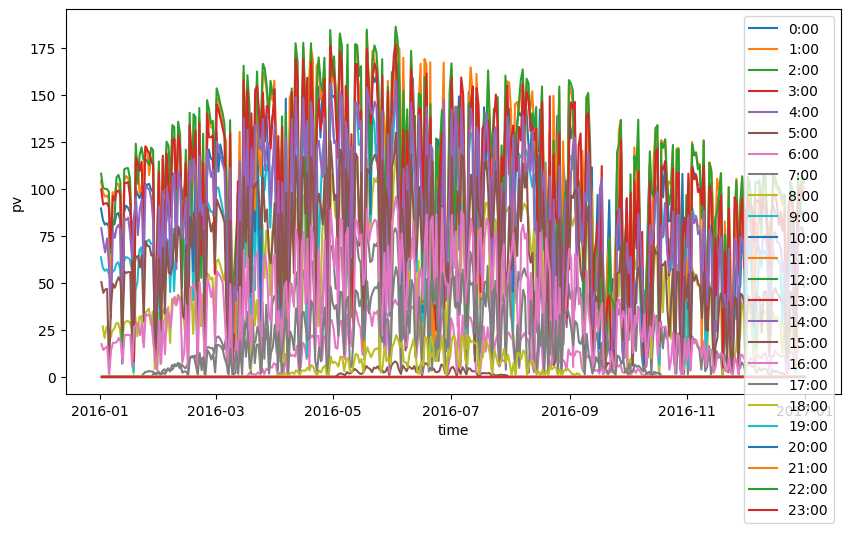

In [14]:
# pvを時間ごとに分解して描画してみる

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(0, 24):
    x = df_weather_yamanashi["jst"][(df_weather_yamanashi["jst"].dt.hour == i) & (df_weather_yamanashi["Year"] == 2016)]
    y = df_weather_yamanashi["pv"][(df_weather_yamanashi["jst"].dt.hour == i) & (df_weather_yamanashi["Year"] == 2016)]

    ax.plot(x, y, label=f"{i}:00")

plt.xlabel("time")
plt.ylabel("pv")
ax.legend()
plt.show()

In [ ]:
# グラフが見えにくくなっているが、発電量に周期性がある

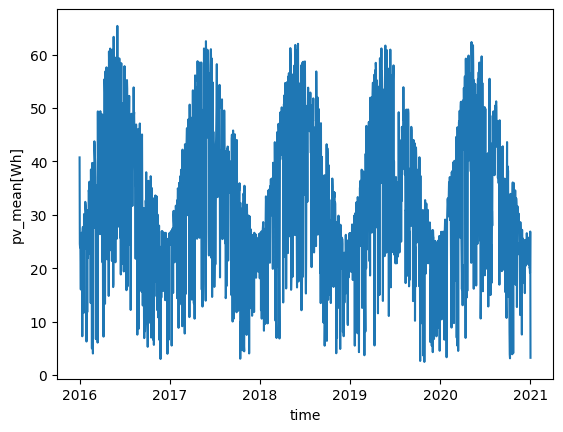

In [ ]:
# pvを日ごとに平均とってみる

# series_pv_mean = df_weather_yamanashi.groupby(df_weather_yamanashi["jst"].dt.dayofyear)["pv"].mean()

series_pv_mean = df_weather_yamanashi.groupby([df_weather_yamanashi["jst"].dt.date])["pv"].mean()

# series_pv_mean = df_weather_yamanashi.groupby([df_weather_yamanashi["jst"].dt.strftime("%m-%d")])["pv"].mean()

plt.plot(series_pv_mean)
# plt.plot(df_pv_mean_by_date.iloc[:, 0], df_pv_mean_by_date.iloc[:, 1])


# plt.tight_layout()
plt.xlabel("time")
plt.ylabel("pv_mean[Wh]")
plt.show()

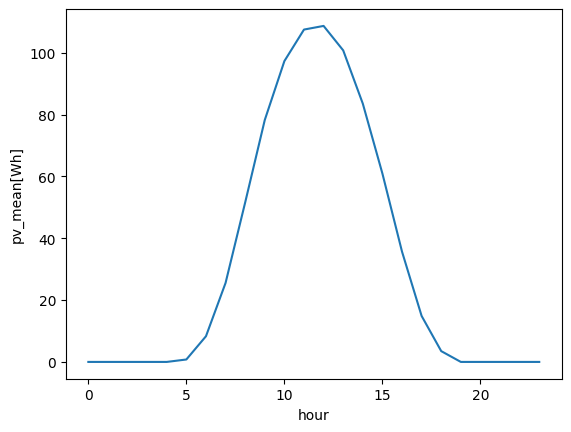

In [18]:
# pvを時間ごとに平均とってみる
series_pv_mean = df_weather_yamanashi.groupby(df_weather_yamanashi["jst"].dt.hour)["pv"].mean()

plt.plot(series_pv_mean)
plt.xlabel("hour")
plt.ylabel("pv_mean[Wh]")
plt.show()

In [ ]:
# 時間ごとに、発電量の平均をとると、周期性が顕著

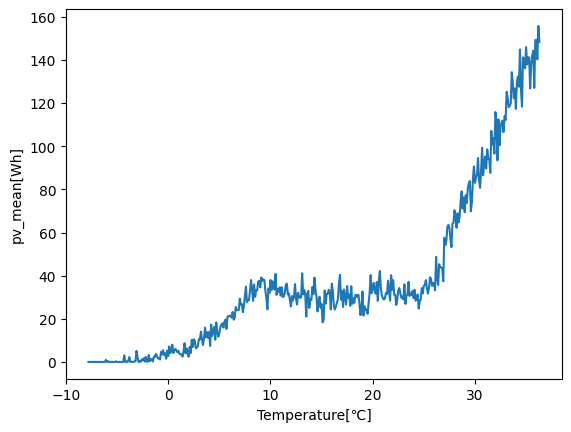

In [19]:
# pvを気温ごとに平均とってみる
series_pv_mean = df_weather_yamanashi.groupby(df_weather_yamanashi["Temperature"])["pv"].mean()

plt.plot(series_pv_mean)
plt.xlabel("Temperature[℃]")
plt.ylabel("pv_mean[Wh]")
plt.show()

In [20]:
# 気温が上がれば発電量も増えているのは、気温が高い＝基本晴れている＝日射量が多い、という可能性がたかい。
# 気温の10度〜２０度後半がのばらつきが小さい。曇りなどの気象条件？

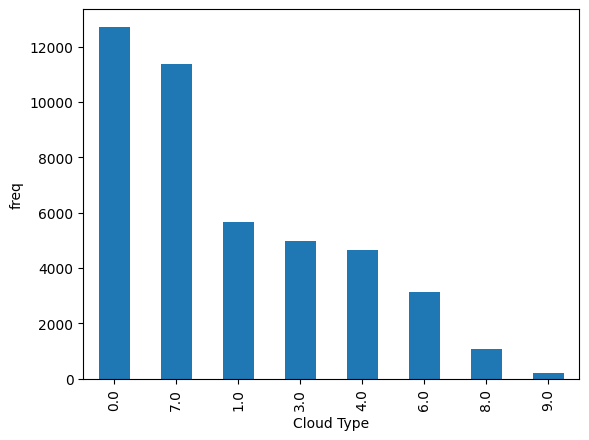

In [21]:
# Cloud typeの分布
# 'Clear': 0, 'Probably Clear': 1, 'Fog': 2, 'Water': 3, 'Super-Cooled Water': 4, 'Mixed': 5, 'Opaque Ice': 6, 'Cirrus': 7, 'Overlapping': 8, 'Overshooting': 9,
df_weather_yamanashi["Cloud Type"].value_counts().plot.bar()
plt.ylabel("freq")
plt.show()

In [ ]:
# 偏りが大きい

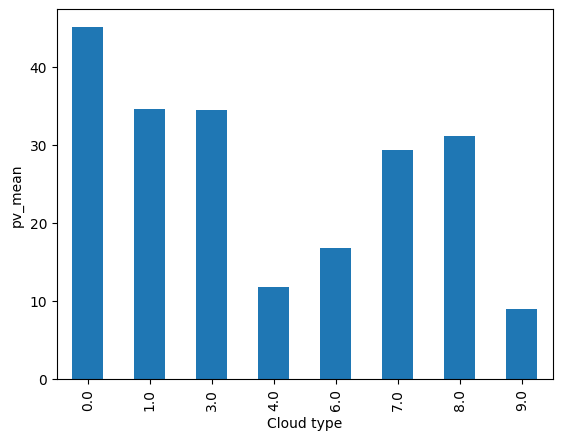

In [22]:
# cloud tyoeごとの発電量の平均
series_pv_mean = df_weather_yamanashi.groupby(df_weather_yamanashi["Cloud Type"])["pv"].mean().plot.bar()
plt.xlabel("Cloud type")
plt.ylabel("pv_mean")
plt.show()



In [24]:
# cloudtypeごとに発電量に偏りがある

0.0
1.0
4.0
7.0
3.0
6.0
9.0
8.0


/var/folders/jd/9q0s8pbn2lx60v_8z7wy2rth0000gn/T/ipykernel_268/123486859.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(list_pv, labels= list_cloudtype)


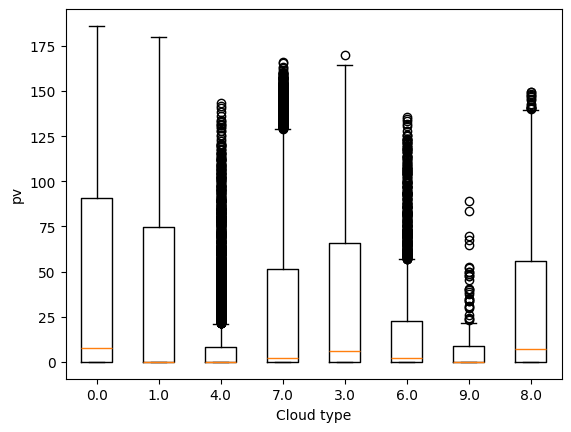

In [25]:
# cloudtypeごとの発電量の箱ヒゲグラフ


list_pv = []
list_cloudtype = []

for i in df_weather_yamanashi["Cloud Type"].unique():
    print(i)

    list = df_weather_yamanashi["pv"][df_weather_yamanashi["Cloud Type"]==i]

    list_cloudtype.append(i)
    list_pv.append(list)

plt.boxplot(list_pv, labels= list_cloudtype)
plt.xlabel("Cloud type")
plt.ylabel("pv")
plt.show()


In [ ]:
# cloud typeによってはばらつきがおおきい